In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras import backend as K
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torch.nn.functional as F

import skfmm

import matplotlib.pyplot as plt
import torch

2024-10-24 10:27:59.544805: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 10:27:59.587150: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-24 10:27:59.588200: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-24 10:28:00.173379: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# # Load the MNIST dataset
# (x_train, _), (x_test, _) = mnist.load_data()
# x_train = x_train.astype('float32') / 255.0
# x_test = x_test.astype('float32') / 255.0
# x_train = np.reshape(x_train, (len(x_train), 28 * 28))
# x_test = np.reshape(x_test, (len(x_test), 28 * 28))

In [3]:
# Custom dataset class
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None, is_image=False):
        self.img_dir = img_dir
        self.transform = transform
        self.img_labels = os.listdir(img_dir)
        self.is_image = is_image

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels[idx])
        if self.is_image:
            image = Image.open(img_path)
        else:
            image = np.load(img_path)
        if self.transform:
            image = self.transform(image)
        return image

In [4]:
# Custom transform to flatten the image tensor
class FlattenTransform:
    def __call__(self, tensor):
        return tensor.reshape(-1)

In [5]:
# Custom transform to flatten the image tensor
class TransposeTransform:
    def __call__(self, tensor):
        return tensor.permute(2,1,0) # is_image=True (2D)
        # return tensor.permute(1,2,0) # is_image=False (3D)

In [6]:
class UnsqueezeTransform:
    def __call__(self, tensor):
        return tensor.unsqueeze(0).unsqueeze(0)

In [7]:
# Custom transform to resize the tensor
class ResizeTransform:
    def __init__(self, size):
        self.size = size
    
    def __call__(self, tensor):
        # Ensure the tensor is in (N, C, D, H, W) format and of float type
        tensor = tensor.unsqueeze(0).unsqueeze(0).float()  # Add batch and channel dimensions and convert to float
        resized_tensor = F.interpolate(tensor, size=self.size, mode='trilinear', align_corners=False)
        return resized_tensor.squeeze(0).squeeze(0)  # Remove batch and channel dimensions

In [8]:
img_dir = "ensembles-png" # use with is_image=True
# img_dir = "ensembles" # use with is_image=False

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # TransposeTransform(), # remove for is_image
    # ResizeTransform((40, 40, 30)), # remove for is_image
    FlattenTransform(),
])
dataset = ImageDataset(img_dir, transform=transform, is_image=True)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [10]:
dataset[0]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [11]:
# calcuate the signed distance for visualization
def plot_orebody_3d(data):
    m_sdf = skfmm.distance(data-0.5)
    plt_contour = np.argwhere((m_sdf<2) & (m_sdf>=-0.5))
    figs = plt.figure(figsize=(7,6))
    ax = figs.add_subplot(1,1,1, projection='3d')
    ax.scatter(plt_contour[:,0], 
            plt_contour[:,1],
            plt_contour[:,2], 
            c = 'y',
            linewidth=0.1,
            edgecolor='k',
            marker='s',
            s=25)
    ax.set_title('Ground truth model', fontsize=18)
#     ax.set_xlim(10, m_sdf.shape[0]-5)
#     ax.set_ylim(5, m_sdf.shape[1]-5)
#     ax.set_zlim(5, m_sdf.shape[2]-5)
    ax.set_xlim(0, m_sdf.shape[0])
    ax.set_ylim(0, m_sdf.shape[1])
    ax.set_zlim(0, m_sdf.shape[2])
    plt.show()

In [12]:
dataset[0].shape

torch.Size([6400])

In [13]:
# plot_orebody_3d(dataset[0])

In [14]:
# Convert the dataset to a tuple of tensors
def dataset_to_tensors(dataset):
    tensors_list = [dataset[i] for i in range(len(dataset))]
    combined_tensor = torch.stack(tensors_list)
    return combined_tensor

In [15]:
X = dataset_to_tensors(dataset)
x_train = X[:900, :].numpy()
x_test = X[900:, :].numpy()
# x_train = x_train.astype('float32')
# x_test = x_test.astype('float32')

In [16]:
x_train.shape, x_test.shape

((900, 6400), (100, 6400))

In [17]:
# Network parameters
original_dim = dataset[0].shape[0]
input_shape = (original_dim,)
intermediate_dim = 256
latent_dim = 2

In [18]:
original_dim

6400

In [42]:
# VAE model = encoder + decoder
# Build the encoder model
inputs = Input(shape=input_shape, name='encoder_input')
x = Dense(intermediate_dim, activation='relu')(inputs)
z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon

# Use the reparameterization trick
z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

# Instantiate the encoder model
encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

# Build the decoder model
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
x = Dense(intermediate_dim, activation='relu')(latent_inputs)
outputs = Dense(original_dim, activation='sigmoid')(x)

# Instantiate the decoder model
decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

# Instantiate the VAE model
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae_mlp')

# Define VAE loss
reconstruction_loss = binary_crossentropy(inputs, outputs) * original_dim
kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)
vae.compile(optimizer=Adam(learning_rate=0.005))

# Train the VAE
vae.fit(x_train,
        epochs=1000, # 1000,
        batch_size=256,
        validation_data=(x_test, None))

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 6400)]               0         []                            
                                                                                                  
 dense_3 (Dense)             (None, 256)                  1638656   ['encoder_input[0][0]']       
                                                                                                  
 z_mean (Dense)              (None, 2)                    514       ['dense_3[0][0]']             
                                                                                                  
 z_log_var (Dense)           (None, 2)                    514       ['dense_3[0][0]']             
                                                                                            

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 2)]               0         
                                                                 
 dense_4 (Dense)             (None, 256)               768       
                                                                 
 dense_5 (Dense)             (None, 6400)              1644800   
                                                                 
Total params: 1645568 (6.28 MB)
Trainable params: 1645568 (6.28 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/1000
4/4 [==============================] - 1s 66ms/step - loss: 2785.9641 - val_loss: 1413.5228
Epoch 2/1000
4/4 [==============================] - 0s 28ms/step - loss: 1199.5447 - val_loss: 915.8697
Epoch 3/1000
4/4 [==============================] - 0s 26ms/step - loss: 977

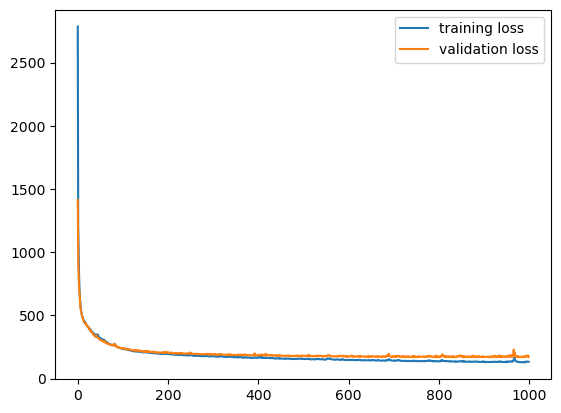

In [43]:
plt.plot(vae.history.history["loss"])
plt.plot(vae.history.history["val_loss"])
plt.legend(["training loss", "validation loss"], loc="upper right")

1/1 [==============================] - 0s 18ms/step


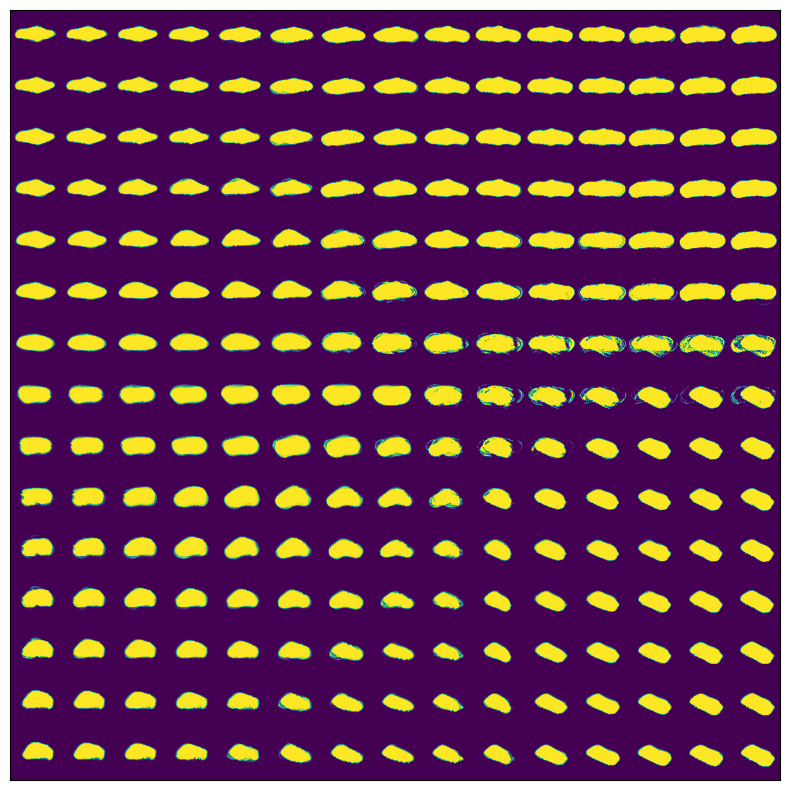

In [44]:
# Display a 2D manifold of the digits
n = 15  # Figure with 15x15 digits
digit_size = 80
digit_size_1 = 40
digit_size_2 = 40
digit_size_3 = 30
figure = np.zeros((digit_size * n, digit_size * n))
# Linearly spaced coordinates corresponding to the 2D plot
# of digit classes in the latent space
grid_x = np.linspace(-4, 4, n)
grid_y = np.linspace(-4, 4, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        # digit = np.round(x_decoded[0].reshape(digit_size, digit_size)).astype(int)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='viridis')
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.show()


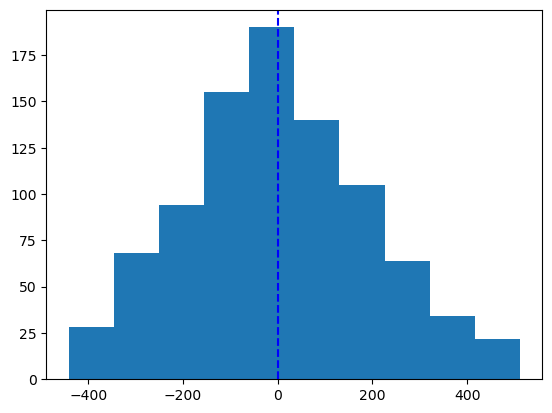

In [45]:
mass_center = np.mean(np.sum(x_train, axis=1))
plt.figure()
plt.hist(np.sum(x_train, axis=1) - mass_center)
plt.axvline([0], color='blue', linestyle='--')

1/1 [==============================] - 0s 19ms/step


1/1 [==============================] - 0s 18ms/step


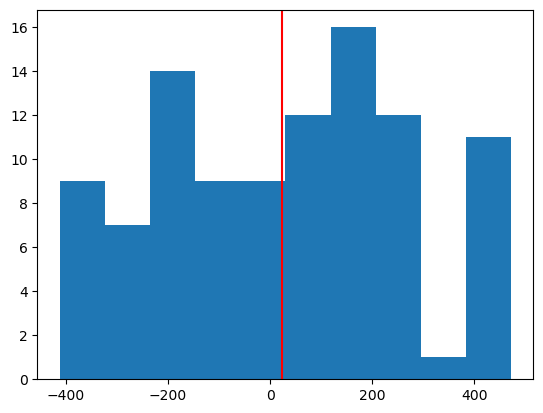

In [40]:
plt.figure()
samples = [np.sum(decoder.predict(np.random.uniform(-4, 4, size=(1,2)))) - mass_center for _ in range(100)]
plt.hist(samples)
plt.axvline(np.mean(samples), color='red')

1/1 [==============================] - 0s 19ms/step


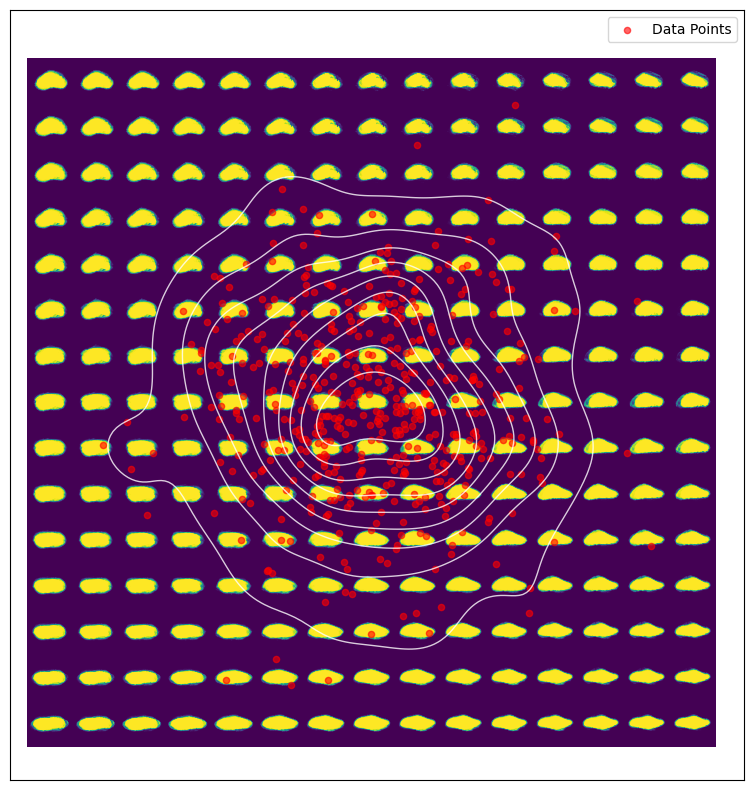

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 1: Prepare Your Data Points ---
# Replace this with your actual data points in the latent space
# Ensure that data_z is a NumPy array of shape (num_points, 2)
# and that the points lie within the range [-4, 4] for both axes.

# Example: Generate 500 random points from a standard normal distribution scaled to [-4, 4]
num_points = 500
data_z = np.random.randn(num_points, 2) * 1.0  # Adjust scaling if necessary

# Optionally, clip the data to ensure it lies within [-4, 4]
data_z = np.clip(data_z, -4, 4)

# --- Step 2: Plot the Manifold ---
n = 15  # Grid size (15x15 digits)
digit_size = 80  # Size of each digit image in pixels
figure = np.zeros((digit_size * n, digit_size * n))

# Linearly spaced coordinates for the 2D latent space
grid_x = np.linspace(-4, 4, n)
grid_y = np.linspace(-4, 4, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
# Set extent to align the image with the latent space coordinates
plt.imshow(figure, cmap='viridis', extent=[-4, 4, -4, 4])
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

# --- Step 3: Add Scatter Points ---
plt.scatter(
    data_z[:, 0],        # X-coordinates
    data_z[:, 1],        # Y-coordinates
    c='red',             # Color of points
    s=20,                # Size of points
    alpha=0.6,           # Transparency
    label='Data Points'  # Label for the legend
)

# --- Step 4: Fit and Plot KDE ---
sns.kdeplot(
    x=data_z[:, 0],
    y=data_z[:, 1],
    levels=10,           # Number of contour levels
    color='white',        # Color of KDE contours
    alpha=0.8,           # Transparency
    linewidths=1,        # Thickness of contour lines
    label='KDE'          # Label for the legend
)

# Optional: Add a legend
plt.legend(loc='upper right')

# Display the combined plot
plt.show()


1/1 [==============================] - 0s 18ms/step


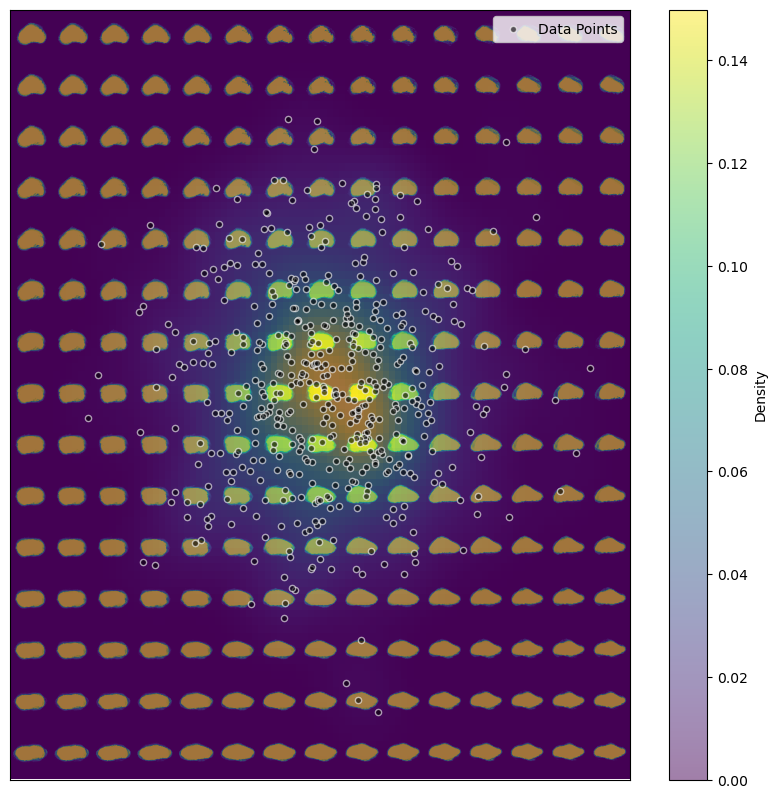

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# --- Step 1: Prepare Your Data Points ---
# Replace this with your actual data points in the latent space
# Ensure that data_z is a NumPy array of shape (num_points, 2)
# and that the points lie within the range [-4, 4] for both axes.

# Example: Generate 500 random points from a standard normal distribution scaled to [-4, 4]
num_points = 500
data_z = np.random.randn(num_points, 2) * 1.0  # Adjust scaling if necessary

# Optionally, clip the data to ensure it lies within [-4, 4]
data_z = np.clip(data_z, -4, 4)

# --- Step 2: Plot the Manifold ---
n = 15  # Grid size (15x15 digits)
digit_size = 80  # Size of each digit image in pixels
figure = np.zeros((digit_size * n, digit_size * n))

# Linearly spaced coordinates for the 2D latent space
grid_x = np.linspace(-4, 4, n)
grid_y = np.linspace(-4, 4, n)

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit

plt.figure(figsize=(10, 10))
# Set extent to align the image with the latent space coordinates
plt.imshow(figure, cmap='viridis', extent=[-4, 4, -4, 4])
ax = plt.gca()
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

# --- Step 3: Add Scatter Points ---
plt.scatter(
    data_z[:, 0],        # X-coordinates
    data_z[:, 1],        # Y-coordinates
    c='black',           # Color of points
    edgecolor='white',   # Color of points
    s=20,                # Size of points
    alpha=0.6,           # Transparency
    label='Data Points'  # Label for the legend
)

# --- Step 4: Compute and Plot KDE as a Transparent Heatmap ---
# Define the grid over which to compute the KDE
kde_grid_size = 100  # Higher value for higher resolution
x_min, x_max = -4, 4
y_min, y_max = -4, 4
x_grid, y_grid = np.linspace(x_min, x_max, kde_grid_size), np.linspace(y_min, y_max, kde_grid_size)
X, Y = np.meshgrid(x_grid, y_grid)
XY = np.vstack([X.ravel(), Y.ravel()])

# Compute the Gaussian KDE
kde = gaussian_kde(data_z.T)
Z = kde(XY).reshape(X.shape)

# Plot the KDE heatmap with transparency
plt.imshow(
    Z, 
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='viridis',
    alpha=0.5,  # Transparency level
    aspect='auto'
)

# Optional: Add a color bar for the KDE heatmap
cbar = plt.colorbar()
cbar.set_label('Density')

# --- Step 5: Final Touches ---
# Optional: Add a legend
plt.legend(loc='upper right')

# Display the combined plot
plt.show()


1/1 [==============================] - 0s 16ms/step


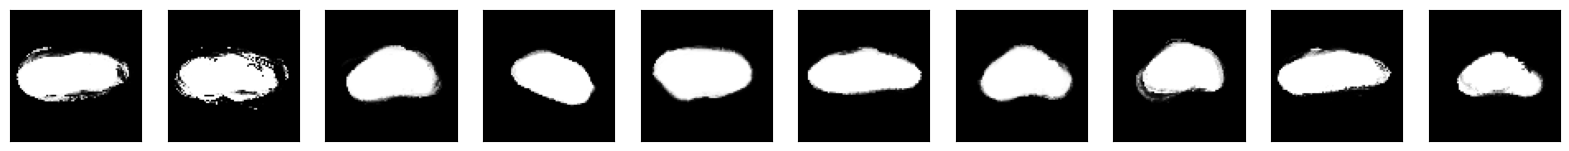

In [35]:
# Sample new images from the latent space
def sample_new_images(num_samples):
    random_points = np.random.normal(size=(num_samples, latent_dim))
    generated_images = decoder.predict(random_points)
    return generated_images

# Generate and display new images
num_samples = 10
new_images = sample_new_images(num_samples)

plt.figure(figsize=(20, 4))
for i in range(num_samples):
    ax = plt.subplot(1, num_samples, i + 1)
    plt.imshow(new_images[i].reshape(80, 80), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [22]:
# Function to sample from the latent space using the reparameterization trick
# def sample_latent_vector(z_mean, z_log_var):
#     epsilon = np.random.normal(size=z_mean.shape)
#     return z_mean + np.exp(0.5 * z_log_var) * epsilon
def sample_latent_vector(z_mean, z_log_var, sigma=1.0):
    # sigma controls the amount of noise (e.g., sigma=0.5 reduces noise, sigma=2.0 increases it)
    epsilon = np.random.normal(size=z_mean.shape) * sigma
    return z_mean + np.exp(0.5 * z_log_var) * epsilon


1/1 [==============================] - 0s 17ms/step


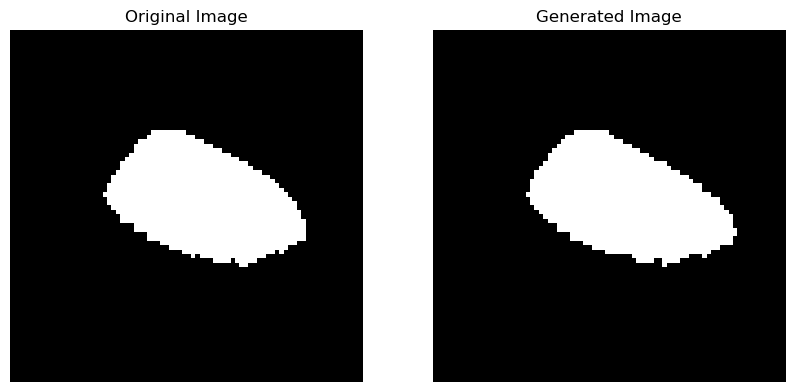

In [36]:
# Get the latent vector (z_mean, z_log_var) from the encoder
encoded = encoder.predict(x_test[:1])  # You can pass a single example or a batch
z_mean, z_log_var, _ = encoded  # The encoder returns z_mean, z_log_var, and z

# Now sample the latent vector
sigma = 1 # 100 # control random noise
latent_vector = sample_latent_vector(z_mean, z_log_var, sigma)

# Generate the image from the latent vector
generated_image = decoder.predict(latent_vector)
generated_image = generated_image.reshape(80, 80)  # Assuming the generated image has the same shape
generated_image = np.round(generated_image)
# plt.imshow(generated_image, cmap='gray')
# plt.show()

# Get the original image
original_image = x_test[0].reshape(80, 80)  # Assuming x_test images are 80x80

# Plot original and generated images side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot original image
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot generated image
axes[1].imshow(generated_image, cmap='gray')
axes[1].set_title("Generated Image")
axes[1].axis('off')

plt.show()

In [24]:
latent_vector

array([[ 4.17147326, -2.52811065]])

1/1 [==============================] - 0s 17ms/step


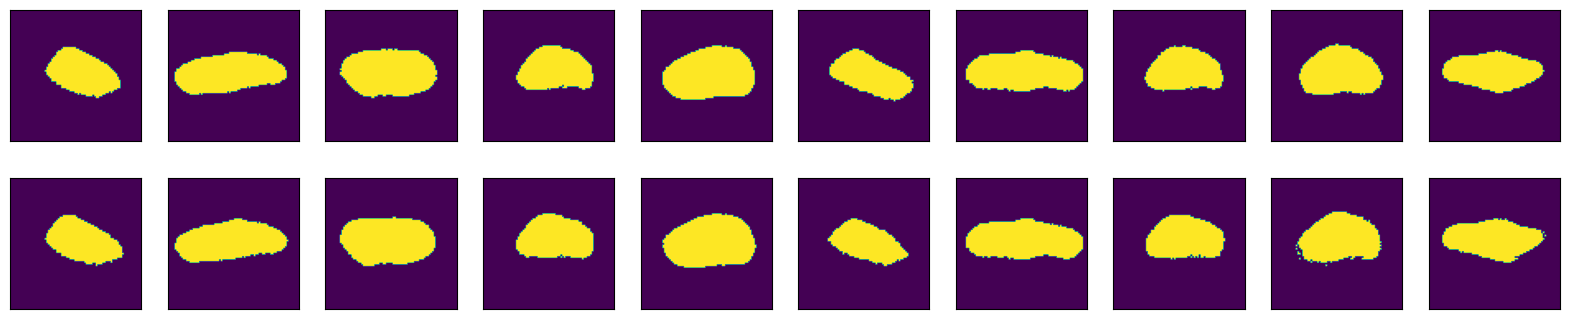

In [37]:
# Plot the original and reconstructed images
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Select an image to encode (for example, the first image in the test set)
    image_to_encode = x_test[i].reshape(1, 80*80)  # Reshape to match input shape

    # Encode the image
    z_mean, z_log_var, _ = encoder.predict(image_to_encode)

    # # Print the latent distribution variables
    # print("z_mean:", z_mean)
    # print("z_std:", np.sqrt(np.exp(z_log_var)))
    # print("z_log_var:", z_log_var)

    # Plot single recreation
    latent_vector = sample_latent_vector(z_mean, z_log_var)
    generated_image = decoder.predict(latent_vector)
    generated_image = generated_image.reshape(digit_size, digit_size)
    generated_image = np.round(generated_image)

    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(image_to_encode.reshape(digit_size, digit_size), cmap='viridis')
    # plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(generated_image, cmap='viridis')
    # plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

# plt.figure(figsize=(10, 10))
# plt.subplot(2, 1, 1)
# plt.imshow(image_to_encode.reshape(digit_size, digit_size), cmap='viridis')
# plt.subplot(2, 1, 2)
# plt.imshow(generated_image, cmap='viridis')
# plt.show()


In [26]:
# Encode and decode some digits
encoded_imgs = encoder.predict(x_test)
# decoded_imgs = decoder.predict(encoded_imgs)

# # Plot the original and reconstructed images
# n = 10  # Number of digits to display
# plt.figure(figsize=(20, 4))
# for i in range(n):
#     # Display original
#     ax = plt.subplot(2, n, i + 1)
#     plt.imshow(x_test[i].reshape(80, 80))
#     plt.gray()
#     ax.get_xaxis().set_visible(False)
#     ax.get_yaxis().set_visible(False)

#     # Display reconstruction
#     ax = plt.subplot(2, n, i + 1 + n)
#     plt.imshow(decoded_imgs[i].reshape(80, 80))
#     plt.gray()
#     ax.get_xaxis().set_visible(False)
#     ax.get_yaxis().set_visible(False)
# plt.show()

4/4 [==============================] - 0s 1ms/step


In [27]:
len(encoded_imgs)

3

In [28]:
# # Define the dimensions of the encoding
# encoding_dim = 36

# # Define the input layer
# input_img = Input(shape=(80*80,))

# # Define the encoding layer
# encoded = Dense(encoding_dim, activation='relu')(input_img)

# # Define the decoding layer
# decoded = Dense(80*80, activation='sigmoid')(encoded)

# # Define the autoencoder model
# autoencoder = Model(input_img, decoded)

# # Define the encoder model
# encoder = Model(input_img, encoded)

# # Define the decoder model
# encoded_input = Input(shape=(encoding_dim,))
# decoder_layer = autoencoder.layers[-1]
# decoder = Model(encoded_input, decoder_layer(encoded_input))

# # Compile the autoencoder
# autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

# # Train the autoencoder
# autoencoder.fit(x_train, x_train,
#                 epochs=100,
#                 batch_size=256,
#                 shuffle=True,
#                 validation_data=(x_test, x_test))

In [29]:
# Get the latent vector from the encoder
encoded_imgs = encoder.predict(x_test)
z_mean, z_log_var, z = encoded_imgs  # The encoder returns z_mean, z_log_var, and z

# Now pass only the latent vector z to the decoder
decoded_imgs = decoder.predict(z)

# Visualize or process the decoded images


4/4 [==============================] - 0s 2ms/step


4/4 [==============================] - 0s 2ms/step


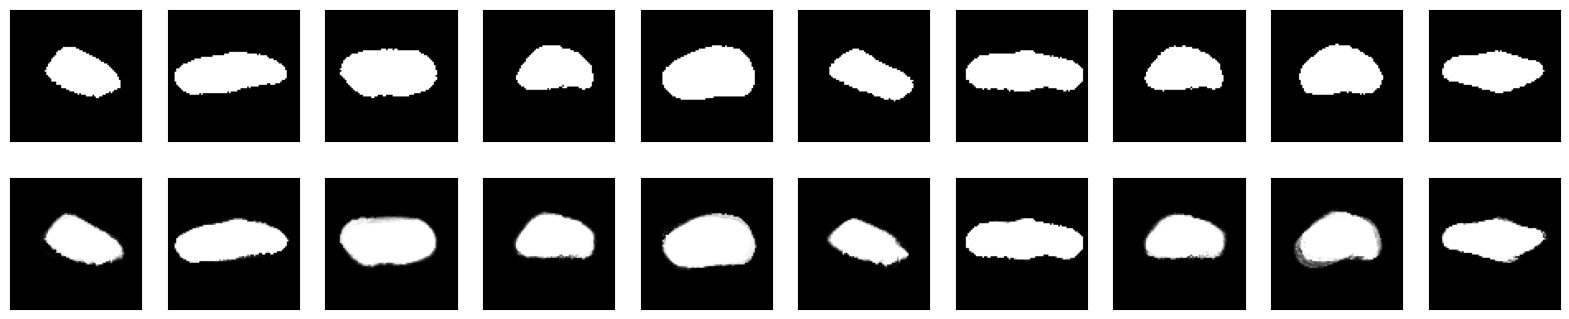

In [38]:
# Encode and decode some digits
# encoded_imgs = encoder.predict(x_test)
# decoded_imgs = decoder.predict(encoded_imgs)

# Get the latent vector from the encoder
encoded_imgs = encoder.predict(x_test)
z_mean, z_log_var, z = encoded_imgs  # The encoder returns z_mean, z_log_var, and z

# Now pass only the latent vector z to the decoder
decoded_imgs = decoder.predict(z)

# Plot the original and reconstructed images
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(80, 80))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(80, 80))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [31]:
def add_noise(data):
    lower = 0
    upper = np.max(data)
    noise = np.random.uniform(lower, upper, data.shape)
    # return np.clip(data + noise, 0, 1)
    return data + noise

IndexError: list index out of range

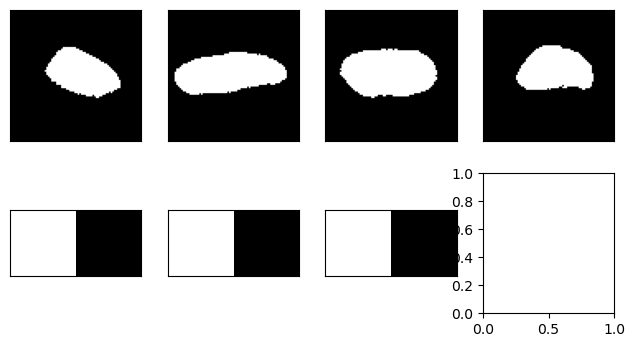

In [41]:
# Plot encoded images
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(80, 80))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display encoding
    ax = plt.subplot(2, n, i + 1 + n)
    # plt.imshow(encoded_imgs[i][2].reshape(6, 6))
    plt.imshow(encoded_imgs[i][1].reshape(1, 2))
    # plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [170]:
decoder.predict(add_noise(encoded_imgs))

1/4 [======>.......................] - ETA: 0s

4/4 [==============================] - 0s 1ms/step


array([[0.0000000e+00, 0.0000000e+00, 4.2539726e-37, ..., 1.7490683e-35,
        1.3675802e-35, 2.6749378e-35],
       [1.0238138e-34, 7.3192043e-37, 1.5130033e-38, ..., 1.1304250e-36,
        3.0137442e-31, 6.1896278e-32],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        8.0409044e-37, 2.2007729e-34],
       ...,
       [1.7444156e-37, 1.0895317e-35, 2.5036943e-36, ..., 5.7894930e-33,
        2.6827735e-29, 8.4211480e-35],
       [5.7953588e-37, 0.0000000e+00, 1.0026784e-36, ..., 2.4186258e-34,
        1.1202705e-32, 1.3646053e-34],
       [6.8329046e-36, 0.0000000e+00, 1.2104276e-33, ..., 0.0000000e+00,
        2.5963369e-30, 2.5982115e-36]], dtype=float32)

4/4 [==============================] - 0s 1ms/step


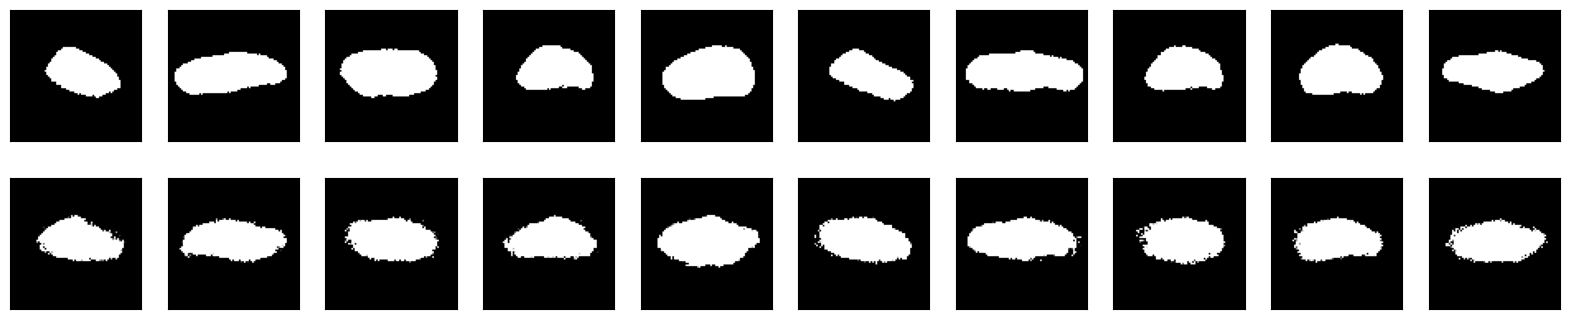

In [173]:
noisy_encoded_imgs = add_noise(encoded_imgs)
noisy_decoded_imgs = decoder.predict(noisy_encoded_imgs)

# Plot encoded images
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(80, 80))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display encoding
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(noisy_decoded_imgs[i].reshape(80, 80))
    # plt.imshow(noisy_encoded_imgs[i].reshape(6, 6))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 784)]                0         []                            
                                                                                                  
 dense_16 (Dense)            (None, 256)                  200960    ['encoder_input[0][0]']       
                                                                                                  
 z_mean (Dense)              (None, 2)                    514       ['dense_16[0][0]']            
                                                                                                  
 z_log_var (Dense)           (None, 2)                    514       ['dense_16[0][0]']            
                                                                                            

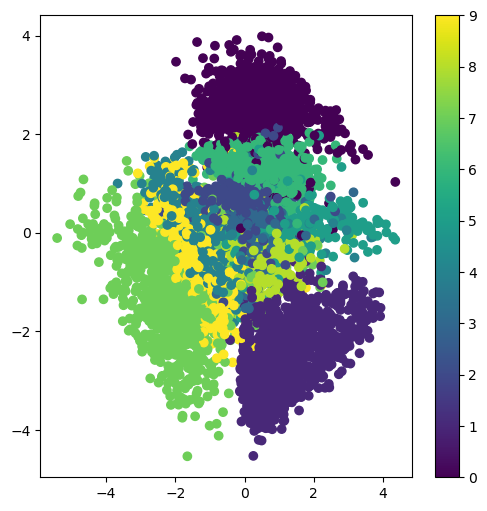

1/1 [==============================] - 0s 18ms/step


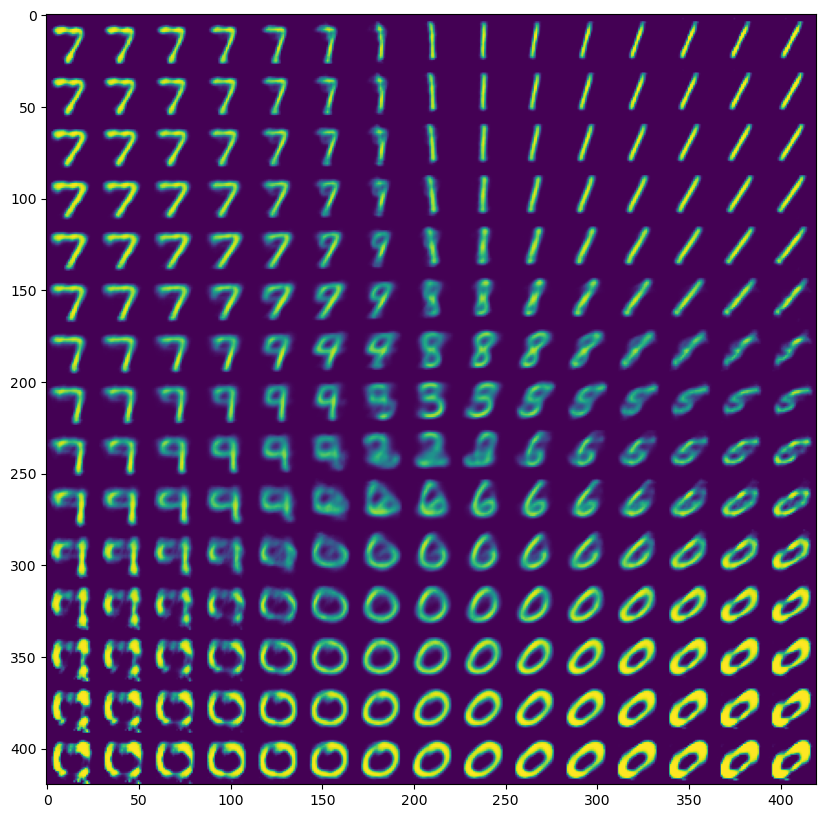

In [174]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Dense, Lambda
# from tensorflow.keras.models import Model
# from tensorflow.keras.losses import binary_crossentropy
# from tensorflow.keras.datasets import mnist
# from tensorflow.keras import backend as K
# import matplotlib.pyplot as plt

# # Load the MNIST dataset
# (x_train, _), (x_test, _) = mnist.load_data()
# x_train = x_train.astype('float32') / 255.0
# x_test = x_test.astype('float32') / 255.0
# x_train = np.reshape(x_train, (len(x_train), 28 * 28))
# x_test = np.reshape(x_test, (len(x_test), 28 * 28))

# # Network parameters
# original_dim = 784
# input_shape = (original_dim,)
# intermediate_dim = 256
# latent_dim = 2

# # VAE model = encoder + decoder
# # Build the encoder model
# inputs = Input(shape=input_shape, name='encoder_input')
# x = Dense(intermediate_dim, activation='relu')(inputs)
# z_mean = Dense(latent_dim, name='z_mean')(x)
# z_log_var = Dense(latent_dim, name='z_log_var')(x)

# def sampling(args):
#     z_mean, z_log_var = args
#     batch = K.shape(z_mean)[0]
#     dim = K.int_shape(z_mean)[1]
#     epsilon = K.random_normal(shape=(batch, dim))
#     return z_mean + K.exp(0.5 * z_log_var) * epsilon

# # Use the reparameterization trick
# z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

# # Instantiate the encoder model
# encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
# encoder.summary()

# # Build the decoder model
# latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
# x = Dense(intermediate_dim, activation='relu')(latent_inputs)
# outputs = Dense(original_dim, activation='sigmoid')(x)

# # Instantiate the decoder model
# decoder = Model(latent_inputs, outputs, name='decoder')
# decoder.summary()

# # Instantiate the VAE model
# outputs = decoder(encoder(inputs)[2])
# vae = Model(inputs, outputs, name='vae_mlp')

# # Define VAE loss
# reconstruction_loss = binary_crossentropy(inputs, outputs) * original_dim
# kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
# kl_loss = K.sum(kl_loss, axis=-1)
# kl_loss *= -0.5
# vae_loss = K.mean(reconstruction_loss + kl_loss)
# vae.add_loss(vae_loss)
# vae.compile(optimizer='adam')

# # Train the VAE
# vae.fit(x_train,
#         epochs=50,
#         batch_size=256,
#         validation_data=(x_test, None))

# # Display a 2D plot of the digit classes in the latent space
# x_test_encoded = encoder.predict(x_test, batch_size=256)[0]
# plt.figure(figsize=(6, 6))
# plt.scatter(x_test_encoded[:, 0], x_test_encoded[:, 1], c=_, cmap='viridis')
# plt.colorbar()
# plt.show()

# # Display a 2D manifold of the digits
# n = 15  # Figure with 15x15 digits
# digit_size = 28
# figure = np.zeros((digit_size * n, digit_size * n))
# # Linearly spaced coordinates corresponding to the 2D plot
# # of digit classes in the latent space
# grid_x = np.linspace(-4, 4, n)
# grid_y = np.linspace(-4, 4, n)

# for i, yi in enumerate(grid_y):
#     for j, xi in enumerate(grid_x):
#         z_sample = np.array([[xi, yi]])
#         x_decoded = decoder.predict(z_sample)
#         digit = x_decoded[0].reshape(digit_size, digit_size)
#         figure[i * digit_size: (i + 1) * digit_size,
#                j * digit_size: (j + 1) * digit_size] = digit

# plt.figure(figsize=(10, 10))
# plt.imshow(figure, cmap='viridis')
# plt.show()


In [172]:
# dummy cell